In [3]:
import pandas as pd
import seaborn as sns

BASELINE = "alone-native"

In [9]:
data = pd.read_csv('cgroup_sched_performance.csv')
alone_copy = data[data["type"] == BASELINE].copy()


def map_row(row):
    alone_rate = alone_copy[alone_copy["segment"] == row["segment"]]["transcode_rate"].values[0]
    row["transcode_rate"] /= alone_rate
    return row

data = data.apply(map_row, axis=1)
data

,type,segment,transcode_rate
0,alone-native,1,1.000000
1,alone-native,2,1.000000
2,alone-native,3,1.000000
3,alone-native,4,1.000000
4,alone-native,5,1.000000
5,alone-native,6,1.000000
6,alone-native,7,1.000000
7,alone-native,8,1.000000
8,alone-cgroup-sched,1,1.024381
9,alone-cgroup-sched,2,1.040798


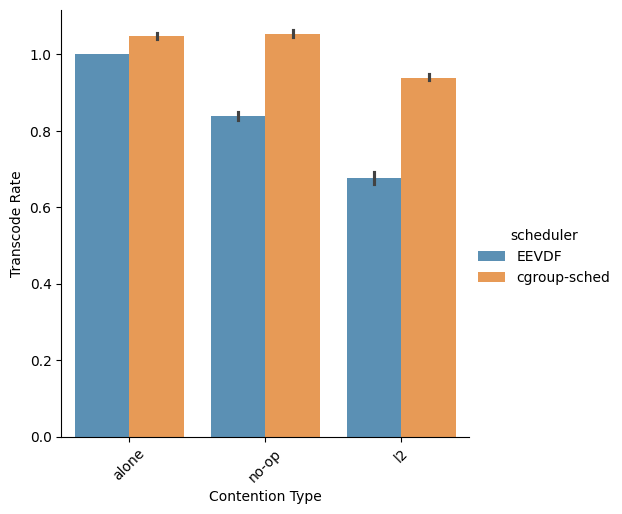

In [41]:
data_prepared = data.copy()
data_prepared["Transcode Rate"] = data_prepared["transcode_rate"]
data_prepared["contention"] = data_prepared["type"].map(
    {
        "alone-native": "alone",
        "alone-cgroup-sched": "alone",
        "spin-native": "no-op",
        "spin-cgroup-sched": "no-op",
        "l2-native": "l2",
        "l2-cgroup-sched": "l2",
    }
)
data_prepared["scheduler"] = data_prepared["type"].map(
    {
        "alone-native": "EEVDF",
        "alone-cgroup-sched": "cgroup-sched",
        "spin-native": "EEVDF",
        "spin-cgroup-sched": "cgroup-sched",
        "l2-native": "EEVDF",
        "l2-cgroup-sched": "cgroup-sched",
    }
)

plot = sns.catplot(
    data=data_prepared,
    x="contention",
    y="Transcode Rate",
    kind="bar",
    hue="scheduler",
    alpha=0.8,
)
plot.set_xticklabels(rotation=45)
plot.set_xlabels("Contention Type")